# AI Final Project — Project 2
## Adversarial Attacks with Torchattacks on CIFAR-10

### Overview

This notebook evaluates adversarial attacks using the `torchattacks` library.

The same baseline and adversarially trained ResNet20 models from the manual implementation notebook are used here. This allows the library-based FGSM and PGD attacks to be compared directly with their manually implemented versions under identical settings.

## Environment and Project Paths

This section configures the notebook for local execution or Google Colab.

The dataset, model checkpoints, downloaded files, and evaluation results are stored in the same project directories used by the manual implementation notebook.

In [1]:
from pathlib import Path
import os

RUN_ON_DRIVE = False

PROJECT_NAME = "adversarial_attacks_and_defenses"


In [2]:
if RUN_ON_DRIVE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "RUN_ON_DRIVE=True requires Google Colab. "
            "Set RUN_ON_DRIVE=False for local execution."
        ) from exc

    DRIVE_MOUNT_DIR = Path("/content/drive")
    drive.mount(str(DRIVE_MOUNT_DIR), force_remount=False)
    PROJECT_DIR = DRIVE_MOUNT_DIR / "MyDrive" / PROJECT_NAME
else:
    current_dir = Path.cwd().resolve()
    PROJECT_DIR = (
        current_dir
        if current_dir.name == PROJECT_NAME
        else current_dir / PROJECT_NAME
    )

PROJECT_DIR = PROJECT_DIR.resolve()

DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"
CACHE_DIR = PROJECT_DIR / "cache"
HF_HOME_DIR = CACHE_DIR / "huggingface"
TORCH_HOME_DIR = CACHE_DIR / "torch"

for directory in (
    PROJECT_DIR,
    DATA_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    HF_HOME_DIR,
    TORCH_HOME_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_HOME_DIR)
os.environ["HF_HUB_CACHE"] = str(HF_HOME_DIR / "hub")
os.environ["TORCH_HOME"] = str(TORCH_HOME_DIR)

print(f"RUN_ON_DRIVE  : {RUN_ON_DRIVE}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"CHECKPOINTS   : {CHECKPOINTS_DIR}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"HF_HOME       : {os.environ['HF_HOME']}")


RUN_ON_DRIVE  : False
PROJECT_DIR   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses
DATA_DIR      : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/data
CHECKPOINTS   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints
RESULTS_DIR   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/results
HF_HOME       : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/cache/huggingface


In [3]:
import sys

!{sys.executable} -m pip install -q torchattacks

In [4]:
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import torchattacks

In [5]:
SEED = 42

In [6]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [7]:
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch version:", torch.__version__)
print("Torchattacks version:", torchattacks.__version__)

Device: cuda
PyTorch version: 2.13.0+cu130
Torchattacks version: 3.5.1


## CIFAR-10 Data Preparation

The CIFAR-10 training and test sets are loaded using the same preprocessing as the manual implementation notebook.

Images remain in the pixel range $[0,1]$ so that adversarial perturbation budgets such as $\epsilon=8/255$ retain their correct pixel-space interpretation.

In [8]:
BATCH_SIZE = 128
NUM_WORKERS = 2

DATA_ROOT = DATA_DIR / "cifar10"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [9]:
raw_transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    transform=raw_transform,
    download=True,
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    transform=raw_transform,
    download=True,
)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

stats_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, labels = next(iter(test_loader))

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Image shape:", images.shape)
print("Pixel range:", images.min().item(), images.max().item())

Train samples: 50000
Test samples: 10000
Image shape: torch.Size([128, 3, 32, 32])
Pixel range: 0.0 1.0


In [10]:
CLEAN_CHECKPOINT_PATH = (
    CHECKPOINTS_DIR / "resnet20_cifar10_clean.pth"
)

ADVERSARIAL_CHECKPOINT_PATH = (
    CHECKPOINTS_DIR / "resnet20_cifar10_adversarial_training.pth"
)

In [11]:
for checkpoint_path in [
    CLEAN_CHECKPOINT_PATH,
    ADVERSARIAL_CHECKPOINT_PATH,
]:
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path.resolve()}"
        )

print("Clean checkpoint:", CLEAN_CHECKPOINT_PATH)
print("Adversarial checkpoint:", ADVERSARIAL_CHECKPOINT_PATH)

Clean checkpoint: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_clean.pth
Adversarial checkpoint: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_adversarial_training.pth


In [12]:
clean_checkpoint = torch.load(
    CLEAN_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)

adversarial_checkpoint = torch.load(
    ADVERSARIAL_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)

## Model Architecture and Checkpoints

The same ResNet20 architecture used in the manual implementation notebook is reconstructed here.

The normalization layer is placed inside the model so that attacks operate directly on images in the valid pixel range $[0,1]$.

$$
x_{\text{norm}}=\frac{x-\mu}{\sigma}
$$

The clean and adversarially trained checkpoints are then loaded for evaluation.

In [13]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()

        mean = torch.as_tensor(
            mean,
            dtype=torch.float32,
        ).view(1, 3, 1, 1)

        std = torch.as_tensor(
            std,
            dtype=torch.float32,
        ).view(1, 3, 1, 1)

        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std

In [14]:
def compute_mean_std(loader):
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0

    for images, _ in loader:
        batch_size, channels, height, width = images.shape

        num_pixels += batch_size * height * width

        channels_sum += images.sum(dim=[0, 2, 3])
        channels_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    mean = channels_sum / num_pixels

    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)

    return mean, std

In [15]:
cifar10_mean, cifar10_std = compute_mean_std(stats_loader)

print("CIFAR-10 mean:", cifar10_mean.tolist())
print("CIFAR-10 std :", cifar10_std.tolist())

CIFAR-10 mean: [0.4913996458053589, 0.48215851187705994, 0.4465310275554657]
CIFAR-10 std : [0.2470322549343109, 0.24348489940166473, 0.2615877091884613]


In [16]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.shortcut(x)
        out = F.relu(out)

        return out

In [17]:
class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(
            out_channels=16,
            num_blocks=3,
            stride=1
        )

        self.layer2 = self._make_layer(
            out_channels=32,
            num_blocks=3,
            stride=2
        )

        self.layer3 = self._make_layer(
            out_channels=64,
            num_blocks=3,
            stride=2
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

In [18]:
def build_resnet20_model(cifar10_mean, cifar10_std, device, num_classes=10):
    resnet20 = ResNet20(num_classes=num_classes)

    model = nn.Sequential(
        Normalize(cifar10_mean, cifar10_std),
        resnet20
    ).to(device)

    return model

In [19]:
clean_model = build_resnet20_model(
    cifar10_mean=cifar10_mean,
    cifar10_std=cifar10_std,
    device=device,
)

adversarial_model = build_resnet20_model(
    cifar10_mean=cifar10_mean,
    cifar10_std=cifar10_std,
    device=device,
)

In [20]:
clean_model.load_state_dict(clean_checkpoint)
adversarial_model.load_state_dict(adversarial_checkpoint)

clean_model = clean_model.to(device)
adversarial_model = adversarial_model.to(device)

clean_model.eval()
adversarial_model.eval()

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [21]:
models = {
    "Clean Training": clean_model,
    "PGD Adversarial Training": adversarial_model,
}

## Clean Accuracy Evaluation

Before applying adversarial attacks, both models are evaluated on the clean CIFAR-10 test set.

This verifies that the architecture and checkpoints have been loaded correctly and provides the clean-accuracy reference for the final comparison.

In [22]:
def evaluate_clean_accuracy(model, loader, device):
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            logits = model(images)
            preds = logits.argmax(dim=1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    accuracy = correct / total
    
    return accuracy

In [23]:
clean_accuracies = {}

for model_name, model in models.items():
    accuracy = evaluate_clean_accuracy(
        model=model,
        loader=test_loader,
        device=device,
    )

    clean_accuracies[model_name] = accuracy

    print(
        f"{model_name}: "
        f"{accuracy * 100:.2f}%"
    )

Clean Training: 89.12%
PGD Adversarial Training: 67.02%


## FGSM Attack

FGSM generates an adversarial image using one step in the direction of the input gradient:

$$
x_{\text{adv}}
=
\operatorname{clip}_{[0,1]}
\left(
x+\epsilon\,
\operatorname{sign}
\left(
\nabla_x L(\theta,x,y)
\right)
\right)
$$

The attack is first evaluated on the clean model using several values of $\epsilon$. It is then applied with $\epsilon=8/255$ to both the clean and adversarially trained models.

In [24]:
FGSM_EPSILONS = [
    0,
    2 / 255,
    4 / 255,
    8 / 255,
    16 / 255
]

In [25]:
def evaluate_attack_accuracy(
    model,
    loader,
    attack,
    device
):
    model.eval()
    
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        adversarial_images = attack(images, labels)
        
        with torch.no_grad():
            logits = model(adversarial_images)
            preds = logits.argmax(dim=1)
            
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    accuracy = correct / total
    
    return accuracy

In [26]:
fgsm_results = []

for epsilon in FGSM_EPSILONS:
    fgsm_attack = torchattacks.FGSM(
        clean_model,
        eps=epsilon
    )
    
    robust_accuracy = evaluate_attack_accuracy(
        model=clean_model,
        loader=test_loader,
        attack=fgsm_attack,
        device=device
    )
    
    fgsm_results.append({
        "epsilon": epsilon,
        "epsilon_pixel": round(epsilon * 255),
        "robust_accuracy": robust_accuracy
    })
    
    print(
        f"epsilon = {round(epsilon * 255)}/255 | "
        f"Robust Accuracy = {robust_accuracy * 100:.2f}%"
    )

epsilon = 0/255 | Robust Accuracy = 89.12%
epsilon = 2/255 | Robust Accuracy = 21.58%
epsilon = 4/255 | Robust Accuracy = 11.49%
epsilon = 8/255 | Robust Accuracy = 7.87%
epsilon = 16/255 | Robust Accuracy = 7.13%


In [27]:
fgsm_results_df = pd.DataFrame(fgsm_results)

fgsm_results_df["robust_accuracy_percent"] = (
    fgsm_results_df["robust_accuracy"] * 100
)

fgsm_results_df

,epsilon,epsilon_pixel,robust_accuracy,robust_accuracy_percent
0,0.000000,0,0.8912,89.12
1,0.007843,2,0.2158,21.58
2,0.015686,4,0.1149,11.49
3,0.031373,8,0.0787,7.87
4,0.062745,16,0.0713,7.13


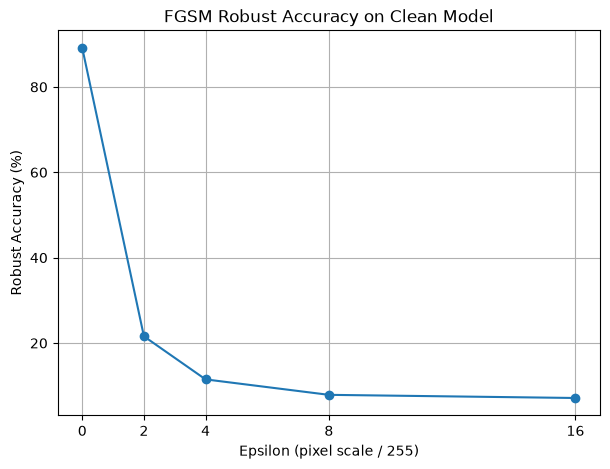

In [28]:
plt.figure(figsize=(7, 5))

plt.plot(
    fgsm_results_df["epsilon_pixel"],
    fgsm_results_df["robust_accuracy_percent"],
    marker="o",
)

plt.xlabel("Epsilon (pixel scale / 255)")
plt.ylabel("Robust Accuracy (%)")
plt.title("FGSM Robust Accuracy on Clean Model")
plt.xticks(fgsm_results_df["epsilon_pixel"])
plt.grid(True)
plt.show()

In [29]:
FGSM_EPSILON = 8 / 255

fgsm_results = []

for model_name, model in models.items():
    fgsm_attack = torchattacks.FGSM(
        model=model,
        eps=FGSM_EPSILON,
    )

    robust_accuracy = evaluate_attack_accuracy(
        model=model,
        loader=test_loader,
        attack=fgsm_attack,
        device=device,
    )

    fgsm_results.append(
        {
            "Model": model_name,
            "Attack": "FGSM",
            "Epsilon": FGSM_EPSILON,
            "Robust Accuracy": robust_accuracy,
        }
    )

    print(
        f"{model_name}: "
        f"{robust_accuracy * 100:.2f}%"
    )

Clean Training: 7.87%
PGD Adversarial Training: 42.45%


In [30]:
fgsm_results_df = pd.DataFrame(fgsm_results)

fgsm_results_df["Robust Accuracy (%)"] = (
    fgsm_results_df["Robust Accuracy"] * 100
)

fgsm_results_df[
    [
        "Model",
        "Attack",
        "Robust Accuracy (%)",
    ]
]

,Model,Attack,Robust Accuracy (%)
0,Clean Training,FGSM,7.87
1,PGD Adversarial Training,FGSM,42.45


## PGD Attack

PGD repeatedly applies small gradient-sign steps and projects the result back into the allowed $L_\infty$ perturbation region:

$$
x^{t+1}
=
\Pi_{x+B_\epsilon}
\left(
x^t+
\alpha\,
\operatorname{sign}
\left(
\nabla_{x^t}L(\theta,x^t,y)
\right)
\right)
$$

The attack uses $\epsilon=8/255$, step size $\alpha=2/255$, 20 iterations, and a random initial point.

In [31]:
PGD_EPSILON = 8 / 255
PGD_ALPHA = 2 / 255
PGD_STEPS = 20
PGD_RANDOM_START = True

In [32]:
pgd_results = []

for model_name, model in models.items(): 
    pgd_attack = torchattacks.PGD(
        model=model,
        eps=PGD_EPSILON,
        alpha=PGD_ALPHA,
        steps=PGD_STEPS,
        random_start=PGD_RANDOM_START
    )
    
    robust_accuracy = evaluate_attack_accuracy(
        model=model,
        loader=test_loader,
        attack=pgd_attack,
        device=device
    )
    
    pgd_results.append(
        {
            "Model": model_name,
            "Attack": "PGD-20",
            "Epsilon": PGD_EPSILON,
            "Alpha": PGD_ALPHA,
            "Steps": PGD_STEPS,
            "Random Start": PGD_RANDOM_START,
            "Robust Accuracy": robust_accuracy,
        }
    )

    print(
        f"{model_name}: "
        f"{robust_accuracy * 100:.2f}%"
    )

Clean Training: 0.00%
PGD Adversarial Training: 39.09%


In [33]:
pgd_results_df = pd.DataFrame(pgd_results)

pgd_results_df["Robust Accuracy (%)"] = (
    pgd_results_df["Robust Accuracy"] * 100
)

pgd_results_df[
    [
        "Model",
        "Attack",
        "Steps",
        "Random Start",
        "Robust Accuracy (%)",
    ]
]

,Model,Attack,Steps,Random Start,Robust Accuracy (%)
0,Clean Training,PGD-20,20,True,0.00
1,PGD Adversarial Training,PGD-20,20,True,39.09


In [34]:
library_results = []

for model_name in models:
    clean_accuracy = clean_accuracies[model_name]

    fgsm_accuracy = fgsm_results_df.loc[
        fgsm_results_df["Model"] == model_name,
        "Robust Accuracy",
    ].iloc[0]

    pgd_accuracy = pgd_results_df.loc[
        pgd_results_df["Model"] == model_name,
        "Robust Accuracy",
    ].iloc[0]

    library_results.append(
        {
            "Model": model_name,
            "Clean": clean_accuracy,
            "FGSM": fgsm_accuracy,
            "PGD-20": pgd_accuracy,
        }
    )

library_results_df = pd.DataFrame(library_results)
library_results_df

,Model,Clean,FGSM,PGD-20
0,Clean Training,0.8912,0.0787,0.0000
1,PGD Adversarial Training,0.6702,0.4245,0.3909


## Final Attack Comparison

The clean accuracy and robust accuracies under FGSM and PGD are collected for both models.

Because the same checkpoints, dataset, preprocessing, and attack parameters are used, these results can be compared directly with the manually implemented attacks from the first notebook.

In [35]:
library_results_percent_df = library_results_df.copy()

for column in ["Clean", "FGSM", "PGD-20"]:
    library_results_percent_df[column] *= 100

library_results_percent_df = library_results_percent_df.round(2)
library_results_percent_df

,Model,Clean,FGSM,PGD-20
0,Clean Training,89.12,7.87,0.00
1,PGD Adversarial Training,67.02,42.45,39.09


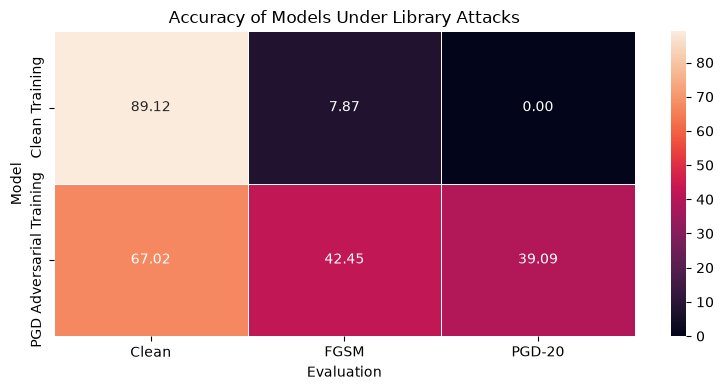

In [36]:
heatmap_data = library_results_percent_df.set_index("Model")

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Accuracy of Models Under Library Attacks")
plt.xlabel("Evaluation")
plt.ylabel("Model")
plt.tight_layout()
plt.show()